# RSG - Radar Sequence generator

This research is about generating radar RD sequences. as in previous research we have seen diffusion model generate impresive RD maps, we decided to try making a sequences generator, making RD sequences closer to reality (relative to simulators)

If this generator will produce the sequences properly, and we could fine-tune it on a small specific dataset, this can help tramendously in radar neural network training.

## Imports & Setup

In [1]:
import sys
from pathlib import Path

import torch

In [2]:
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)

In [3]:
from src.simulator import generate_sequences
from src.viz import (show_clutter_correlation, show_cuts, show_brightness,
                     show_normalization, show_range_profile, show_rows, show_sequence)


## Simulated Dataset

### 0. generate sequences function

`generate_sequences` creates labelled RD sequences from the simulator in one call.

**How to set it**
- Any setting you leave out is random, drawn the same way as the training data.
- A single value applies to every target. A list gives one value per target, and its length sets the number of targets.

| parameter | meaning | if left out |
|---|---|---|
| `n` | number of sequences | 1 |
| `seq_len` | frames per sequence, 0.5 s apart | 16 |
| `n_targets` | targets per sequence (1–5) | random |
| `target_class` | `"steady"`, `"swerling1"` (power fluctuates every frame) or `"extended"` (spread over 3 range bins) | random |
| `snr_db` | target strength in dB | random, −5 to 10 dB |
| `clutter`, `noise` | background clutter and receiver noise, on or off | on |
| `rho`, `nu` | clutter frame-to-frame correlation (0–1) and spikiness | random |
| `r0`, `v0`, `a` | initial range (m), radial velocity (m/s), acceleration (m/s²) | random, kept inside the map |
| `seed` | fixes the random draws, so a run repeats exactly | not fixed |

**What it returns**, a dict of tensors:
- `x`: the sequences in dB, shape `(n, seq_len, 64, 64)`, ordered (sequence, frame, range bin, Doppler bin)
- `traj`: the true target position in every frame as (range bin, Doppler bin), shape `(n, 5, seq_len, 2)`
- `v0`, `acc`, `cls`: each target's initial velocity, acceleration and class, shape `(n, 5)`
- `env`: `[CNR, SCNR, rho]` for each sequence
- `n_targets`: how many of the 5 target slots are real; the rest are zero padding

Each step below changes one thing. Red circles mark the true target positions.

### 1. Constant velocity

One target moving at constant speed, with no clutter and no noise.

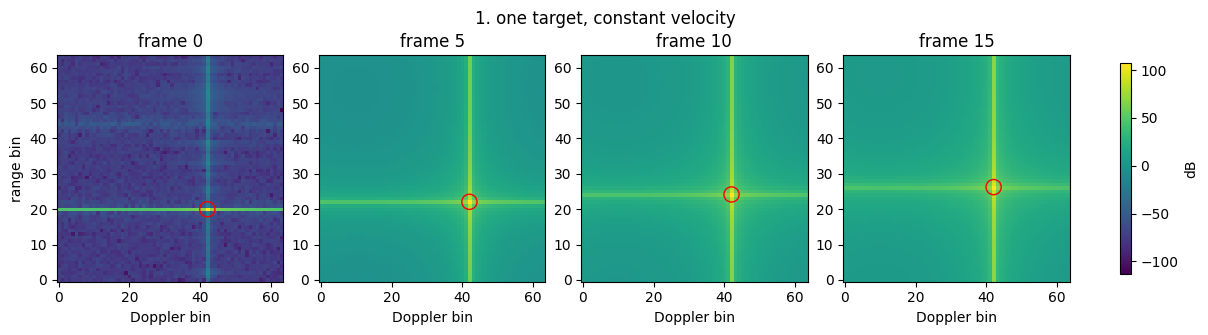

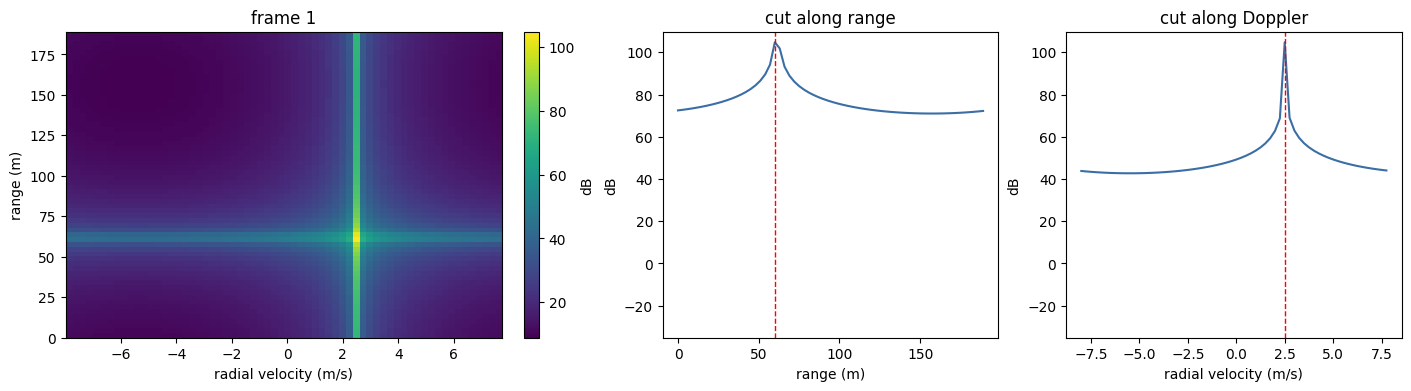

In [4]:
# one static target on an empty map
# static = generate_sequences(n_targets=1, target_class="steady", snr_db=20, clutter=False, noise=False, r0=90, v0=0, a=0, seed=0)
# show_sequence(static, frames=(0,), title="one static target")

constant = generate_sequences(n_targets=1, target_class="steady", snr_db=20, clutter=False, noise=False, r0=60, v0=2.5, a=0, seed=0)
show_sequence(constant, title="1. one target, constant velocity")
show_cuts(constant, t=1)

### 2. Acceleration

The same target, now accelerating: its Doppler drifts too, so the track bends.

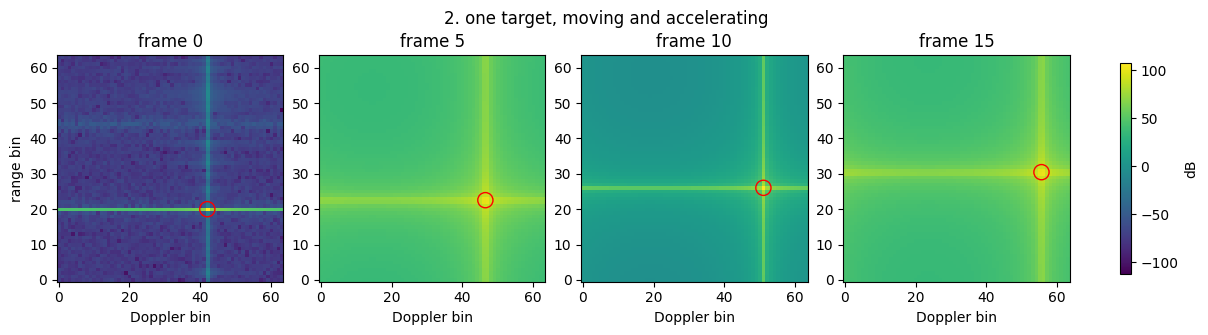

In [5]:
moving = generate_sequences(n_targets=1, target_class="steady", snr_db=20, clutter=False, noise=False, r0=60, v0=2.5, a=0.45, seed=0)
show_sequence(moving, title="2. one target, moving and accelerating")

### 3. Receiver noise

The accelerating target without and with receiver noise, on one colour scale.


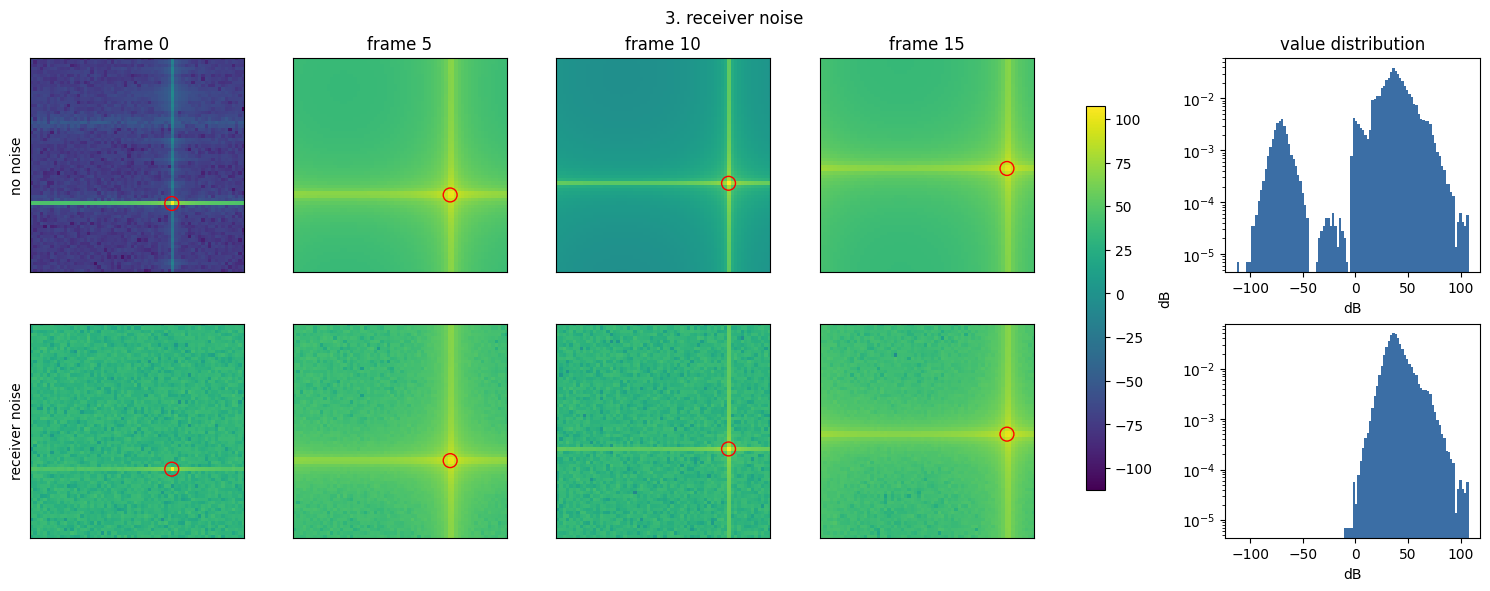

In [6]:
noisy = generate_sequences(n_targets=1, target_class="steady", snr_db=20, clutter=False, noise=True, r0=60, v0=2.5, a=0.45, seed=0)
show_rows([moving, noisy], ["no noise", "receiver noise"], title="3. receiver noise", hist=True)

### 4. Clutter

- **Rows:** smooth (`nu=1.5`) vs spiky (`nu=0.1`) clutter. The band and the stripes stay in place from frame to frame.
- **Correlation plot:** `rho` only changes the fine speckle, which is too subtle to see, so it is measured. The clutter signal's frame-to-frame correlation (blue) follows `rho`; the dB map's (orange) stays high because the band and stripes don't move.

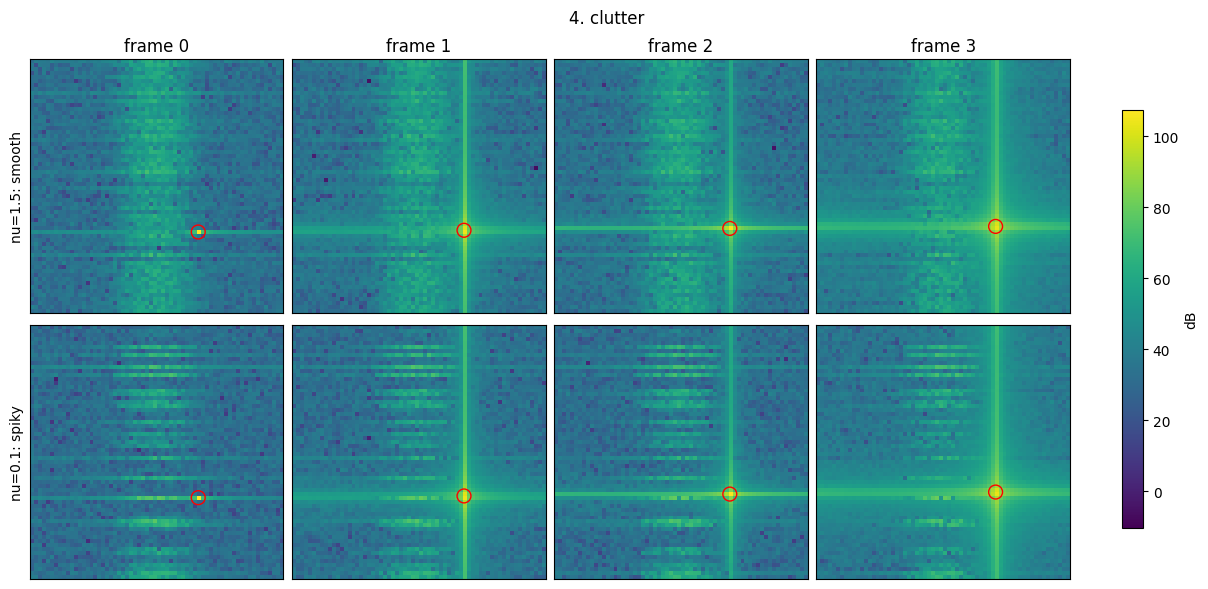

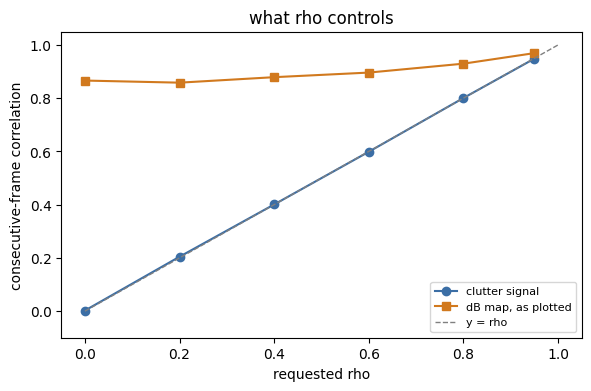

In [7]:
smooth = generate_sequences(n_targets=1, target_class="steady", snr_db=20, rho=0.95, nu=1.5, r0=60, v0=2.5, a=0.45, seed=0)
spiky = generate_sequences(n_targets=1, target_class="steady", snr_db=20, rho=0.95, nu=0.1, r0=60, v0=2.5, a=0.45, seed=0)
show_rows([smooth, spiky], ["nu=1.5: smooth", "nu=0.1: spiky"], frames=(0, 1, 2, 3), title="4. clutter")
show_clutter_correlation()

### 5. Target strength

The same clutter three times. Here it fills a band around Doppler bin 31.
- **Rows:** a weak target outside the band, the same weak target inside it, and a strong target inside it. Inside the band the weak target drops from about 36 to 23 dB above its background; the strong one stands out again.

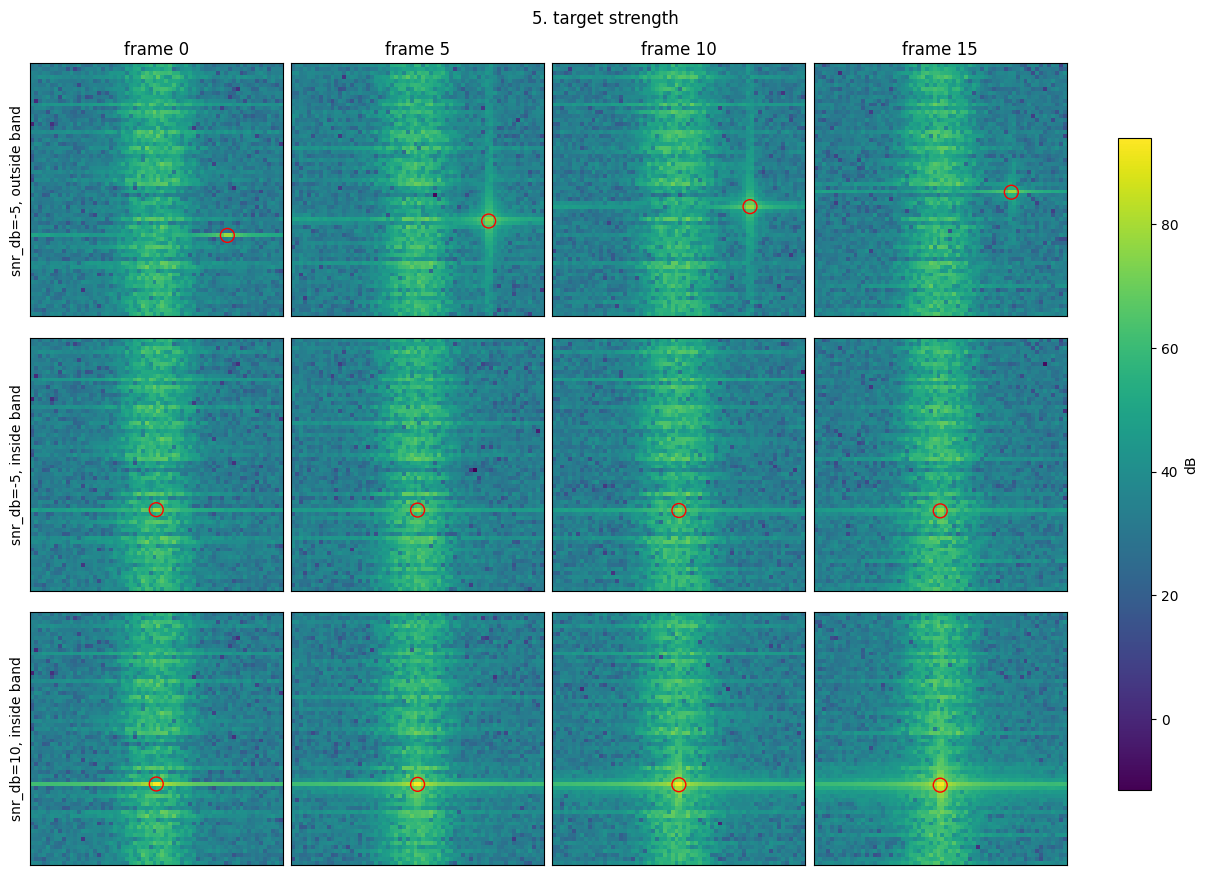

In [8]:
weak_outside = generate_sequences(n_targets=1, target_class="steady", snr_db=-5, rho=0.5, nu=1.0, r0=60, v0=4.37, a=0, seed=0)
weak_inside = generate_sequences(n_targets=1, target_class="steady", snr_db=-5, rho=0.5, nu=1.0, r0=60, v0=-0.12, a=0, seed=0)
strong_inside = generate_sequences(n_targets=1, target_class="steady", snr_db=10, rho=0.5, nu=1.0, r0=60, v0=-0.12, a=0, seed=0)
show_rows([weak_outside, weak_inside, strong_inside], ["snr_db=-5, outside band", "snr_db=-5, inside band", "snr_db=10, inside band"], title="5. target strength")

### 6. Target classes

- **Rows:** steady, Swerling-1 and extended targets with the same motion.
- **Peak brightness:** the target's brightness in each frame. Steady and extended targets dip only a little when they fall between bins; Swerling-1 jumps from frame to frame.
- **Range profile:** a static target on an empty map. A point target fills one range bin; an extended target fills three.

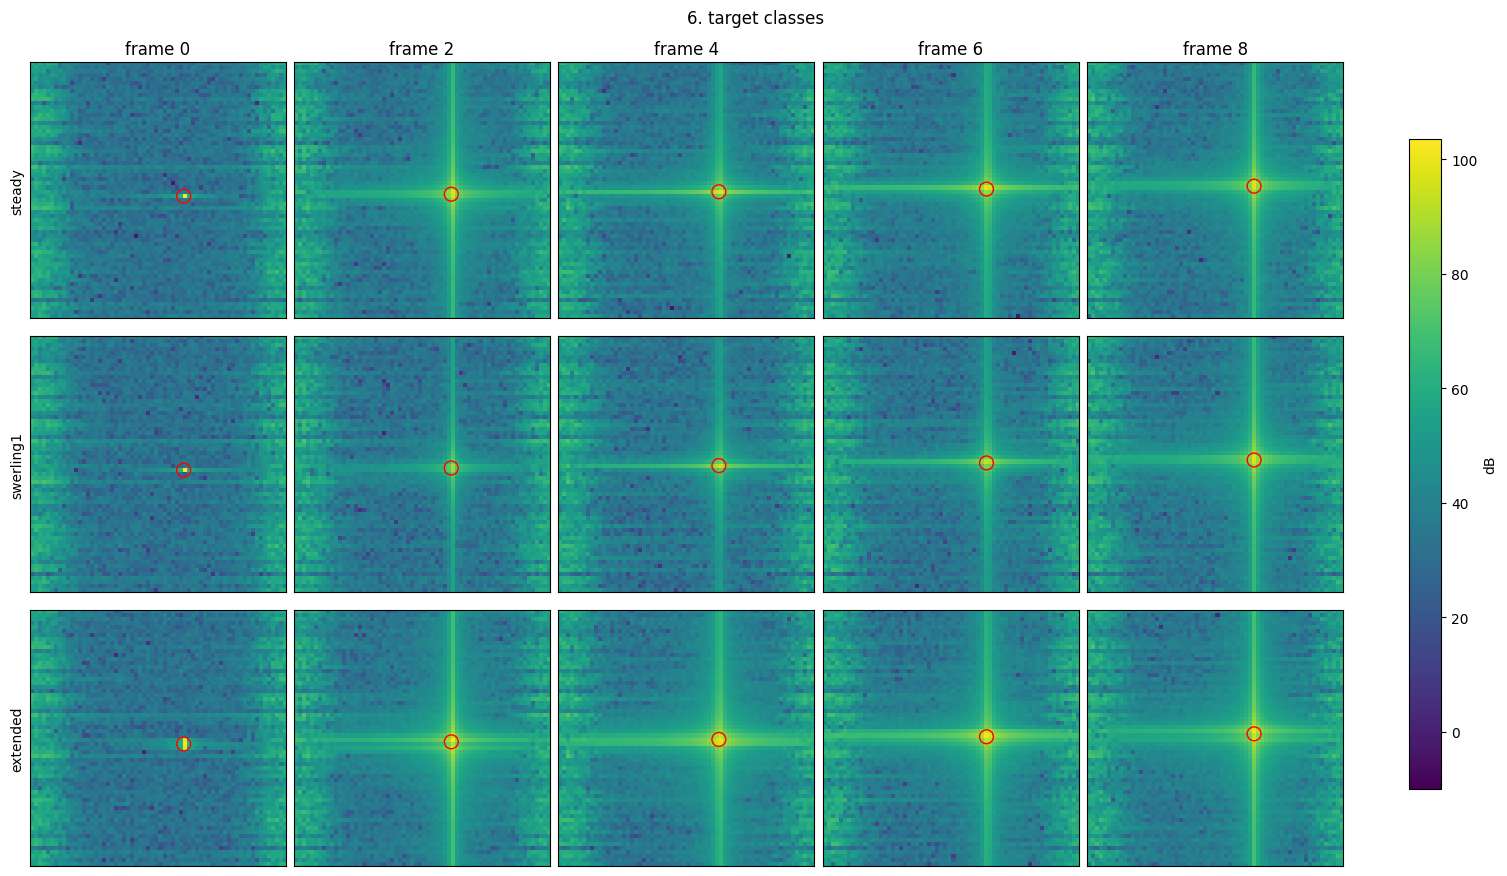

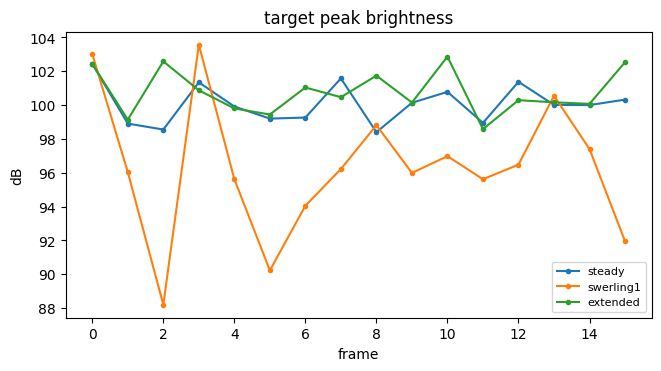

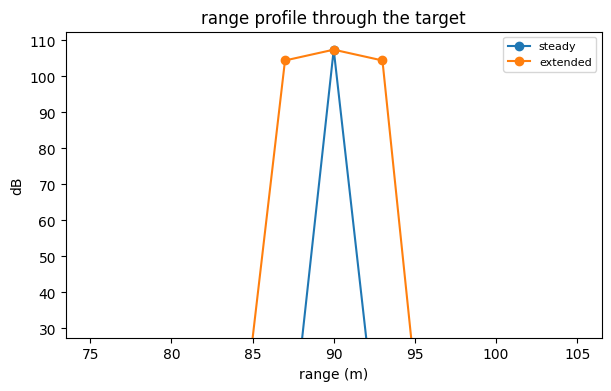

In [9]:
classes = [generate_sequences(n_targets=1, target_class=c, snr_db=15, rho=0.5, nu=1.0, r0=90, v0=1.5, a=0.2, seed=3) for c in ("steady", "swerling1", "extended")]
show_rows(classes, ["steady", "swerling1", "extended"], frames=(0, 2, 4, 6, 8), title="6. target classes")
show_brightness(classes, ["steady", "swerling1", "extended"])
point = generate_sequences(n_targets=1, target_class="steady", snr_db=20, clutter=False, noise=False, r0=90, v0=0, a=0, seed=0)
extended = generate_sequences(n_targets=1, target_class="extended", snr_db=20, clutter=False, noise=False, r0=90, v0=0, a=0, seed=0)
show_range_profile([point, extended], ["steady", "extended"])

### 7. Several targets

Three targets starting at 40, 90 and 150 m; their speeds and accelerations are random.

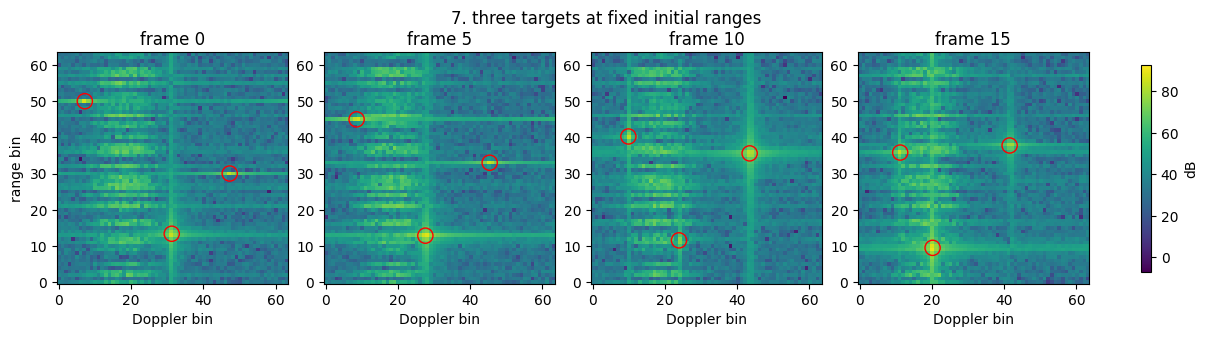

In [10]:
three = generate_sequences(n=8, r0=[40, 90, 150], seed=0)
show_sequence(three, title="7. three targets at fixed initial ranges")

### 8. The full training distribution


Every setting random: this is the kind of sequence the model trains on.

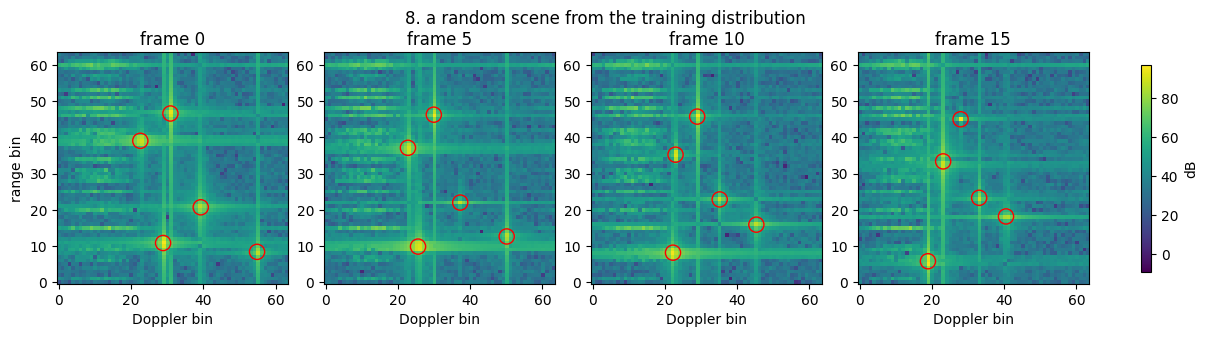

In [11]:
full = generate_sequences(n=8, seed=0)
show_sequence(full, title="8. a random scene from the training distribution")

## Normalization

The model is a diffusion model: it learns by adding random noise of size 1 to the data and then removing it. That only works if the data is on the same scale as the noise, so every map is rescaled before the model sees it:

$$x_{\text{norm}} = \frac{x_{\text{dB}} - \text{mean}}{\text{std}}$$

- `mean` and `std` are two numbers, computed **once** over every pixel of the 20,000 training sequences.
- The **same pair** is used for all data: training, validation and generated. A given dB value always maps to the same number, so a strong target stays stronger than a weak one.
- Going back to dB is the reverse: `x_dB = x_norm × std + mean` (`denormalize` in `src/dataset.py`).


### 1. The two numbers
Saved when the training set was built.


In [12]:
stats = torch.load(ROOT / "data" / "cache" / "stats.pt")
print(f"mean = {stats['mean']:.2f} dB, std = {stats['std']:.2f} dB")


mean = 41.48 dB, std = 11.07 dB


### 2. Before and after
64 random sequences from the training distribution, normalised with those two numbers.
- **Left, raw:** the values in dB. Black is the mean; grey is one std either side.
- **Right, normalised:** the bulk now sits around 0 with a spread of about 1, the same scale as the diffusion noise. Targets are the thin tail on the right: the dashed lines mark where the brightest 1% (about 2.5) and 0.1% (about 4) of pixels start. That tail is the part the generator later struggles to reproduce.


after normalising: mean 0.01, std 1.00


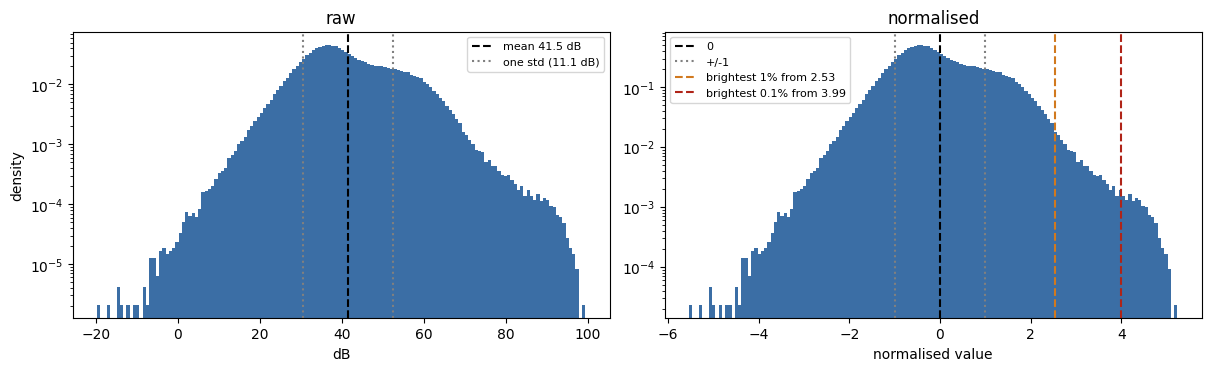

In [13]:
batch = generate_sequences(n=64, seed=0)
x_norm = (batch["x"] - stats["mean"]) / stats["std"]
print(f"after normalising: mean {x_norm.mean():.2f}, std {x_norm.std():.2f}")
show_normalization(batch["x"], stats)


## Learned sequence generators — easy and full regimes

These are the **working structured models**. Each checkpoint learns the distribution of target motion from the training cache. The model samples scene variables; the radar simulator renders the target returns. The full-regime model also samples the learned target-count and class frequencies, then draws fresh target strengths, clutter and receiver noise from the simulator. This is different from the original pixel-space DiT, which still fails when sampling from noise.

Red circles below mark the **known target trajectories** of generated and held-out sequences. The model checkpoints are `checkpoints/easy_latent.pt` and `checkpoints/hard_latent.pt`. Run the cells from the repository root or this `notebooks/` directory.

In [14]:
from src.dataset import RadarSequenceDataset, denormalize
from src.easy_latent import generate as generate_easy_learned
from src.hard_latent import generate as generate_hard_learned
from src.eval.metrics import marginal_l1


def held_out_batch(dataset, n=32, offset=0):
    items = [dataset[i] for i in range(offset, offset + n)]
    return {
        "x": torch.stack([denormalize(item["x"], dataset.stats) for item in items]),
        "traj": torch.stack([item["traj"] for item in items]),
        "n_targets": torch.stack([item["n_targets"] for item in items]),
    }


def print_distribution_check(generated, reference, second_reference, stats):
    z_gen = (generated["x"] - stats["mean"]) / stats["std"]
    z_real = (reference["x"] - stats["mean"]) / stats["std"]
    print(f"normalized std: generated {z_gen.std():.3f} | held-out {z_real.std():.3f}")
    print(f"marginal L1: generated vs held-out {marginal_l1(generated['x'], reference['x']):.3f} "
          f"| held-out vs held-out {marginal_l1(second_reference['x'], reference['x']):.3f}")
    print(f"true targets/sequence: generated {generated['n_targets'].float().mean():.2f} "
          f"| held-out {reference['n_targets'].float().mean():.2f}")

### Easy regime: one moving target, no clutter or receiver noise

The learned model samples velocity and acceleration, then places one target at a physically valid initial range. The renderer produces all 16 RD frames. The two rows use one shared dB color scale.

EASY REGIME — 32 generated sequences, seed 1
normalized std: generated 1.020 | held-out 1.001
marginal L1: generated vs held-out 0.054 | held-out vs held-out 0.062
true targets/sequence: generated 1.00 | held-out 1.00


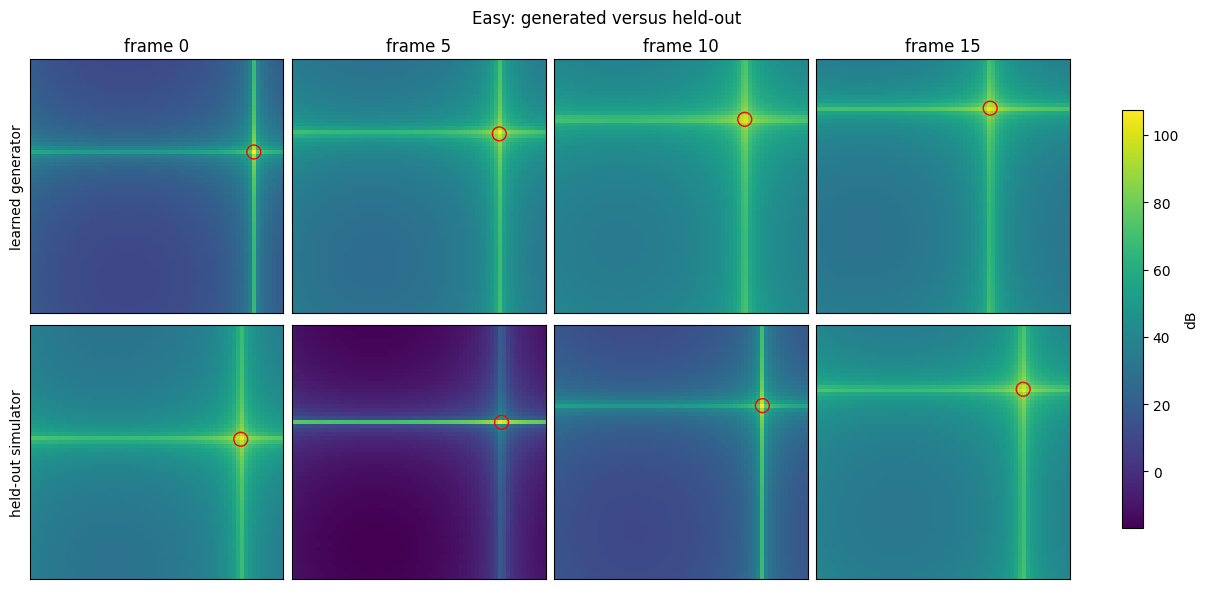

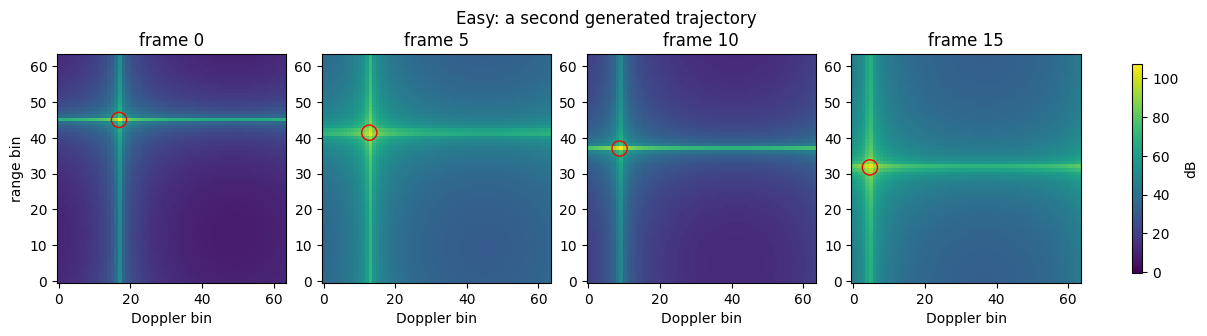

In [15]:
easy_ckpt = ROOT / "checkpoints" / "easy_latent.pt"
assert easy_ckpt.exists(), f"Missing {easy_ckpt}; run python -m src.easy_latent --steps 50000"
easy_gen = generate_easy_learned(easy_ckpt, 32, seed=1, device=device)
easy_val = RadarSequenceDataset(ROOT / "data" / "cache_easy", "val")
easy_real = held_out_batch(easy_val, 32)
easy_real_2 = held_out_batch(easy_val, 32, offset=32)
print("EASY REGIME — 32 generated sequences, seed 1")
print_distribution_check(easy_gen, easy_real, easy_real_2, easy_val.stats)
show_rows([easy_gen, easy_real], ["learned generator", "held-out simulator"],
          frames=(0, 5, 10, 15), title="Easy: generated versus held-out")
show_sequence(easy_gen, i=1, title="Easy: a second generated trajectory")

### Full regime: multiple targets, classes, clutter and noise

The full model samples 1–5 targets and their classes and motion. The radar simulator then supplies fresh target phases and strengths, K-distributed clutter with temporal correlation, and receiver noise. As above, both rows share a dB color scale.

FULL REGIME — 32 generated sequences, seed 1
normalized std: generated 1.007 | held-out 1.000
marginal L1: generated vs held-out 0.061 | held-out vs held-out 0.065
true targets/sequence: generated 2.97 | held-out 3.41
true targets/sequence in all 2000 held-out sequences: 2.96


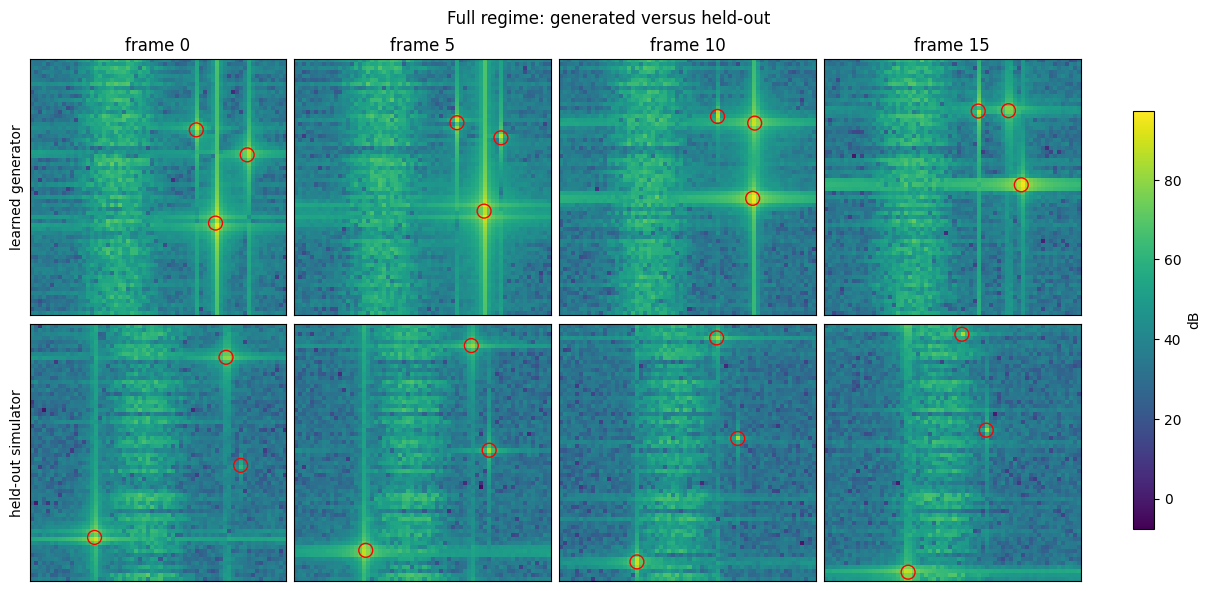

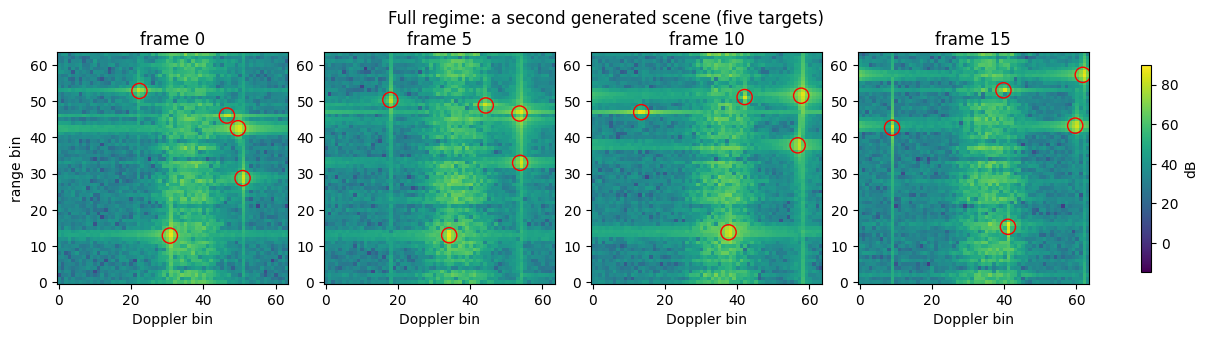

In [16]:
hard_ckpt = ROOT / "checkpoints" / "hard_latent.pt"
assert hard_ckpt.exists(), f"Missing {hard_ckpt}; run python -m src.hard_latent --steps 50000"
hard_gen = generate_hard_learned(hard_ckpt, 32, seed=1, device=device)
hard_val = RadarSequenceDataset(ROOT / "data" / "cache", "val")
hard_real = held_out_batch(hard_val, 32)
hard_real_2 = held_out_batch(hard_val, 32, offset=32)
print("FULL REGIME — 32 generated sequences, seed 1")
print_distribution_check(hard_gen, hard_real, hard_real_2, hard_val.stats)
print(f"true targets/sequence in all {len(hard_val)} held-out sequences: "
      f"{sum(int(item['n_targets']) for item in hard_val.items) / len(hard_val):.2f}")
show_rows([hard_gen, hard_real], ["learned generator", "held-out simulator"],
          i=4, frames=(0, 5, 10, 15), title="Full regime: generated versus held-out")
show_sequence(hard_gen, i=20, title="Full regime: a second generated scene (five targets)")

The printed distribution checks compare 32 generated sequences with disjoint held-out draws. A close histogram alone cannot prove scene quality, so the plots show the complete target paths and use shared color scales. These checks establish fidelity to the **synthetic simulator distribution**; they do not validate real-radar fidelity or repair the original pixel-space diffusion model.

## The diffusion model (DiT)

Everything above draws its maps with the simulator. From here on the maps come from the **DiT itself**: it starts from pure noise and removes it step by step, with no simulator involved.

The recipe that works (`docs/notes/2026-09-15-e3-longer-training.md`): v-prediction, a noise schedule shifted towards high noise, no clamp on the model's estimate, non-overlapping 8×8 patches, attention over time and over space in turn (45 M parameters), EMA weights, 30 sampling steps.

The DiT is **unconditional**: it invents its own random scene, so its rows have no target circles, and the simulator and DiT rows show different scenes.

### Inside the DiT — the code

The cells below are the whole model and sampler, written out. They compute exactly what `src/dit.py` and `src/diffusion.py` compute for the configuration that works (non-overlapping 8×8 patches, factorized attention, v-prediction, schedule shift 4). The last cell loads the trained weights into this code and checks that it gives the same output as `src`.

**1. Patches.** Each 64×64 frame is cut into 64 non-overlapping 8×8 patches; each patch becomes one token.

In [ ]:
import math
import torch.nn as nn
import torch.nn.functional as F

PATCH = 8


def to_patches(x):
    """(B, L, 64, 64) -> (B, L, 64 tokens, 64 values): 8x8 patches, row by row."""
    B, L, N, K = x.shape
    x = x.reshape(B, L, N // PATCH, PATCH, K // PATCH, PATCH)
    return x.permute(0, 1, 2, 4, 3, 5).reshape(B, L, (N // PATCH) * (K // PATCH), PATCH * PATCH)


def from_patches(tokens, N=64, K=64):
    """Inverse of to_patches."""
    B, L = tokens.shape[:2]
    x = tokens.reshape(B, L, N // PATCH, K // PATCH, PATCH, PATCH)
    return x.permute(0, 1, 2, 4, 3, 5).reshape(B, L, N, K)

**2. Noise level as a vector.** The diffusion timestep t becomes sinusoidal features; an MLP inside the model turns them into the vector every block is conditioned on.

In [ ]:
def timestep_embedding(t, dim):
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
    args = t.float()[:, None] * freqs[None]
    return torch.cat([torch.cos(args), torch.sin(args)], dim=-1)

**3. Attention.** Standard multi-head self-attention. The weights are kept in `nn.MultiheadAttention` so trained checkpoints load; the computation uses PyTorch's fused attention kernel.

In [ ]:
def attend(attn, h):
    """Self-attention over the sequence axis of h: (batch, tokens, width)."""
    B, T, d = h.shape
    q, k, v = F.linear(h, attn.in_proj_weight, attn.in_proj_bias).chunk(3, dim=-1)
    q, k, v = (u.view(B, T, attn.num_heads, d // attn.num_heads).transpose(1, 2) for u in (q, k, v))
    out = F.scaled_dot_product_attention(q, k, v)
    return attn.out_proj(out.transpose(1, 2).reshape(B, T, d))

**4. One block: time, then space, then MLP.** Attention across the 16 frames at each patch position lets a patch follow its content through time; attention across the 64 patches of a frame lets the frame agree on one scene. Each sub-layer is shifted, scaled and gated by the noise-level vector (adaLN-Zero: the gates start at zero, so an untrained block changes nothing).

In [ ]:
class FactorizedBlock(nn.Module):
    def __init__(self, dim, heads):
        super().__init__()
        self.norm_t = nn.LayerNorm(dim, elementwise_affine=False, eps=1e-6)
        self.attn_t = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.norm_s = nn.LayerNorm(dim, elementwise_affine=False, eps=1e-6)
        self.attn_s = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim, elementwise_affine=False, eps=1e-6)
        self.mlp = nn.Sequential(nn.Linear(dim, 4 * dim), nn.GELU(), nn.Linear(4 * dim, dim))
        self.adaLN = nn.Sequential(nn.SiLU(), nn.Linear(dim, 9 * dim))   # shift, scale, gate for 3 sub-layers
        nn.init.zeros_(self.adaLN[1].weight)
        nn.init.zeros_(self.adaLN[1].bias)

    def forward(self, z, c):
        B, L, P, d = z.shape   # batch, frames, patches per frame, width
        sh_t, sc_t, g_t, sh_s, sc_s, g_s, sh_m, sc_m, g_m = self.adaLN(c)[:, None, None].chunk(9, dim=-1)
        # time: each patch position attends over the 16 frames
        h = (self.norm_t(z) * (1 + sc_t) + sh_t).permute(0, 2, 1, 3).reshape(B * P, L, d)
        z = z + g_t * attend(self.attn_t, h).reshape(B, P, L, d).permute(0, 2, 1, 3)
        # space: the 64 patches of each frame attend to each other
        h = (self.norm_s(z) * (1 + sc_s) + sh_s).reshape(B * L, P, d)
        z = z + g_s * attend(self.attn_s, h).reshape(B, L, P, d)
        # MLP on every token
        return z + g_m * self.mlp(self.norm2(z) * (1 + sc_m) + sh_m)

**5. The whole model.** Patches → tokens, plus a learned position within the frame and in time → 12 blocks → one output patch per token → maps. With v-prediction the output is *v*, a known mix of the noise and the clean map (step 6 shows how both are recovered from it).

In [ ]:
class DiT(nn.Module):
    def __init__(self, dim=384, depth=12, heads=6, frames=16, n_patches=64):
        super().__init__()
        self.dim = dim
        self.proj = nn.Linear(PATCH * PATCH, dim)
        self.spatial_pos = nn.Parameter(torch.zeros(1, 1, n_patches, dim))
        self.temporal_pos = nn.Parameter(torch.zeros(1, frames, 1, dim))
        self.t_mlp = nn.Sequential(nn.Linear(dim, dim), nn.SiLU(), nn.Linear(dim, dim))
        self.blocks = nn.ModuleList(FactorizedBlock(dim, heads) for _ in range(depth))
        self.final_norm = nn.LayerNorm(dim, elementwise_affine=False, eps=1e-6)
        self.final_adaLN = nn.Sequential(nn.SiLU(), nn.Linear(dim, 2 * dim))
        self.out = nn.Linear(dim, PATCH * PATCH)

    def forward(self, x, t):
        z = self.proj(to_patches(x)) + self.spatial_pos + self.temporal_pos
        c = self.t_mlp(timestep_embedding(t, self.dim))
        for block in self.blocks:
            z = block(z, c)
        shift, scale = self.final_adaLN(c)[:, None, None].chunk(2, dim=-1)
        return from_patches(self.out(self.final_norm(z) * (1 + scale) + shift))


print(f"parameters: {sum(p.numel() for p in DiT().parameters()) / 1e6:.1f} M")

parameters: 45.0 M


**6. Noise schedule and training objective.** `abar[t]` is how much of the clean map survives at noise level t. The cosine schedule is shifted by s = 4, dividing every level's signal-to-noise ratio by 16: a 16×64×64 sequence is so redundant that its scene is visible at very low SNR, so training needs more noisy levels. Training noises a clean normalised sequence to a random level and asks the model for v.

In [ ]:
def alphas_bar(T=1000, shift=4.0):
    t = torch.arange(T + 1, dtype=torch.float64) / T
    f = torch.cos((t + 0.008) / 1.008 * math.pi / 2) ** 2
    betas = torch.clamp(1 - (f[1:] / f[0]) / (f[:-1] / f[0]), max=0.999)
    abar = torch.cumprod(1 - betas, dim=0)
    return (abar / (abar + shift ** 2 * (1 - abar))).float()   # SNR / shift^2


def training_loss(model, x0, abar):
    """x0: clean normalised sequences (B, 16, 64, 64)."""
    t = torch.randint(0, len(abar), (x0.shape[0],))
    ab = abar[t].view(-1, 1, 1, 1)
    eps = torch.randn_like(x0)
    xt = ab.sqrt() * x0 + (1 - ab).sqrt() * eps          # noisy input
    v = ab.sqrt() * eps - (1 - ab).sqrt() * x0           # what the model must output
    return F.mse_loss(model(xt, t), v)

**7. Sampling (DDIM, 30 steps).** Start from pure noise. At each step predict v, recover the model's estimate of the clean map x0 and of the noise, and move to the next, less noisy level with them. The last step returns x0.

In [ ]:
@torch.no_grad()
def ddim_sample(model, abar, n, steps=30, seed=None, frames=16, device="cpu"):
    if seed is not None:
        torch.manual_seed(seed)
    x = torch.randn(n, frames, 64, 64, device=device)
    ts = torch.linspace(len(abar) - 1, 0, steps).long()
    abar = abar.to(device)
    for i, t in enumerate(ts):
        ab = abar[t]
        v = model(x, t.repeat(n).to(device))
        x0 = ab.sqrt() * x - (1 - ab).sqrt() * v         # clean-map estimate
        eps = (1 - ab).sqrt() * x + ab.sqrt() * v        # noise estimate
        if i == steps - 1:
            return x0
        ab_next = abar[ts[i + 1]]
        x = ab_next.sqrt() * x0 + (1 - ab_next).sqrt() * eps

**8. Check: this code is the trained DiT.** Load the full-regime model's EMA weights into the notebook's `DiT` (every weight name must match) and compare with `src` on the same input, then on a whole 30-step sample from the same starting noise.

In [ ]:
from src.train import build_model
from src.sample import generate

ckpt_path = ROOT / "checkpoints" / "e3_long_bs32" / "last.pt"
ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
dit = DiT()
dit.load_state_dict(ckpt["ema_model"], strict=True)
dit.eval()
reference = build_model(ckpt["config"], torch.device("cpu"))
reference.load_state_dict(ckpt["ema_model"])
reference.eval()

x, t = torch.randn(2, 16, 64, 64), torch.tensor([100, 800])
with torch.no_grad():
    print("one forward pass, max difference:", float((dit(x, t) - reference(x, t)).abs().max()))

ours = ddim_sample(dit, alphas_bar(), n=1, seed=7) * stats["std"] + stats["mean"]
theirs = generate(ckpt_path, n_seq=1, device=torch.device("cpu"), steps=30, weights="ema", seed=7)
print("30-step sample, max difference (dB):", float((ours - theirs).abs().max()))

one forward pass, max difference: 0.0


30-step sample, max difference (dB): 0.0


### Easy regime: one moving target, no clutter or receiver noise

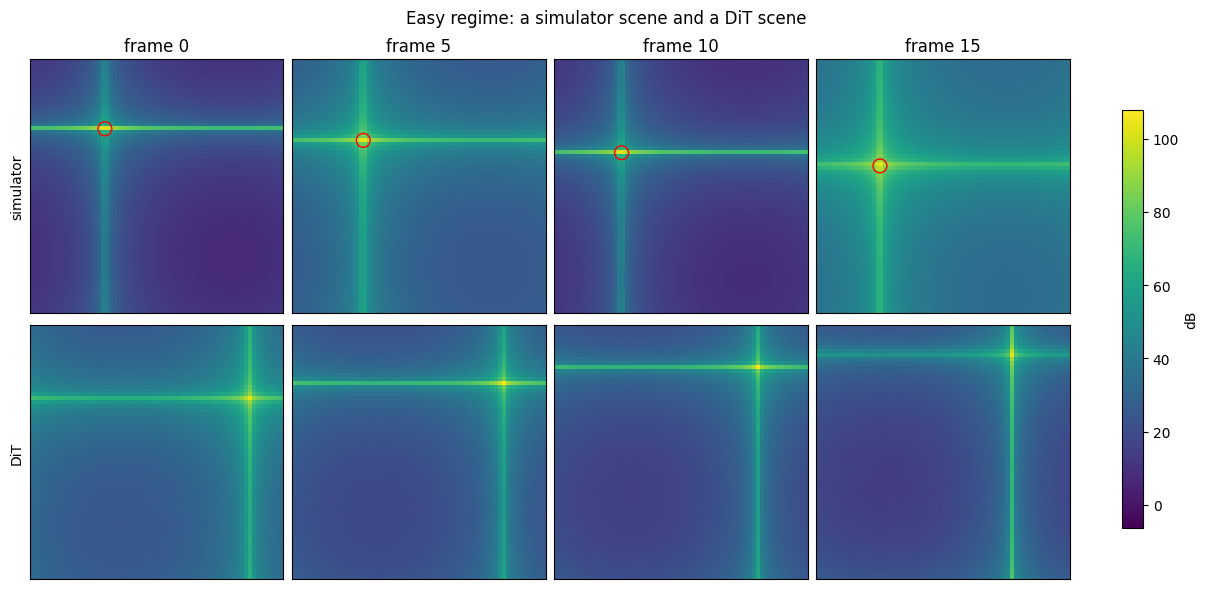

In [ ]:
from src.sample import generate

easy_dit = generate(ROOT / "checkpoints" / "e0_standard_bs32" / "last.pt", n_seq=4,
                    device=device, steps=30, weights="ema", seed=1)
easy_sim = generate_sequences(n=4, n_targets=1, target_class="steady", snr_db=20,
                              clutter=False, noise=False, seed=1)
show_rows([easy_sim, {"x": easy_dit}], ["simulator", "DiT"],
          title="Easy regime: a simulator scene and a DiT scene")

### Full regime: multiple targets, classes, clutter and noise

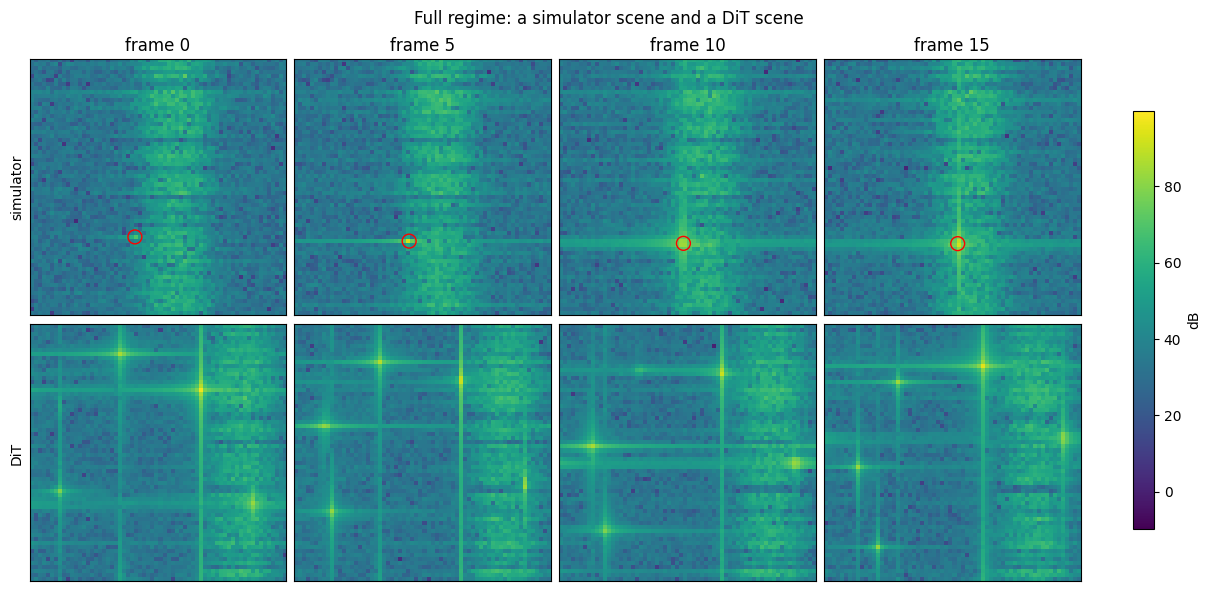

In [ ]:
full_ckpt = ROOT / "checkpoints" / "e3_long_bs32" / "last.pt"
full_dit = torch.cat([generate(full_ckpt, n_seq=32, device=device, steps=30, weights="ema", seed=s)
                      for s in (1, 2, 3)])
full_sim = generate_sequences(n=4, seed=1)
show_rows([full_sim, {"x": full_dit}], ["simulator", "DiT"],
          title="Full regime: a simulator scene and a DiT scene")

### Does the full-regime DiT pass the four checks?

The 96 DiT sequences are compared with held-out simulator sequences, using the same detector and tracker as every earlier experiment. **real vs real** compares two disjoint sets of 32 held-out sequences: it is the best any generator can score.

- **std** — contrast of the normalised map. Pass: within 0.1 of real.
- **marginal L1** — how different the mix of pixel brightnesses is (0 = identical, 2 = no overlap). Pass: ≤ 0.15.
- **target tracks per sequence** — detections that link across at least 8 of the 16 frames, i.e. real targets rather than clutter blips. Pass: within 15 % of real.
- **persistence** — the fraction of all linked detections that last at least 13 of 16 frames. Too low means flicker. Pass: within 25 % of real.

In [ ]:
from src.eval.metrics import evaluate_sequences

full_val = RadarSequenceDataset(ROOT / "data" / "cache", "val")
ref_a, ref_b = held_out_batch(full_val, 32), held_out_batch(full_val, 32, offset=32)
real = evaluate_sequences(ref_a["x"], ref_b["x"])
dit = evaluate_sequences(full_dit, ref_b["x"])
real["std"] = float(((ref_b["x"] - stats["mean"]) / stats["std"]).std())
dit["std"] = float(((full_dit - stats["mean"]) / stats["std"]).std())

checks = {
    "std": abs(dit["std"] - real["std"]) <= 0.1,
    "marginal_l1": dit["marginal_l1"] <= 0.15,
    "n_target_tracks_per_seq": abs(dit["n_target_tracks_per_seq"] - real["n_target_tracks_per_seq"])
                               <= 0.15 * real["n_target_tracks_per_seq"],
    "persistence": abs(dit["persistence"] - real["persistence"]) <= 0.25 * real["persistence"],
}
print(f"{'check':26s} {'real vs real':>12s} {'DiT':>8s}")
for name, ok in checks.items():
    print(f"{name:26s} {real[name]:12.3f} {dit[name]:8.3f}   {'pass' if ok else 'FAIL'}")

check                      real vs real      DiT
std                               1.004    0.939   pass
marginal_l1                       0.065    0.079   pass
n_target_tracks_per_seq           3.094    3.188   pass
persistence                       0.144    0.123   pass


This is one draw of 96 sequences, so persistence moves by roughly ±0.01 between runs; the result over 6 seeds is in `samples/e3_long_scores.json` (all four checks pass). As in the section above, these checks measure fidelity to the **simulator**, not to real radar. Remaining gaps: detections last slightly less long than in the simulator (persistence ≈ 0.12 vs 0.14) and target motion is slightly jerkier.